In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


对比图已保存至: Refined_Results_v4\6.pdf


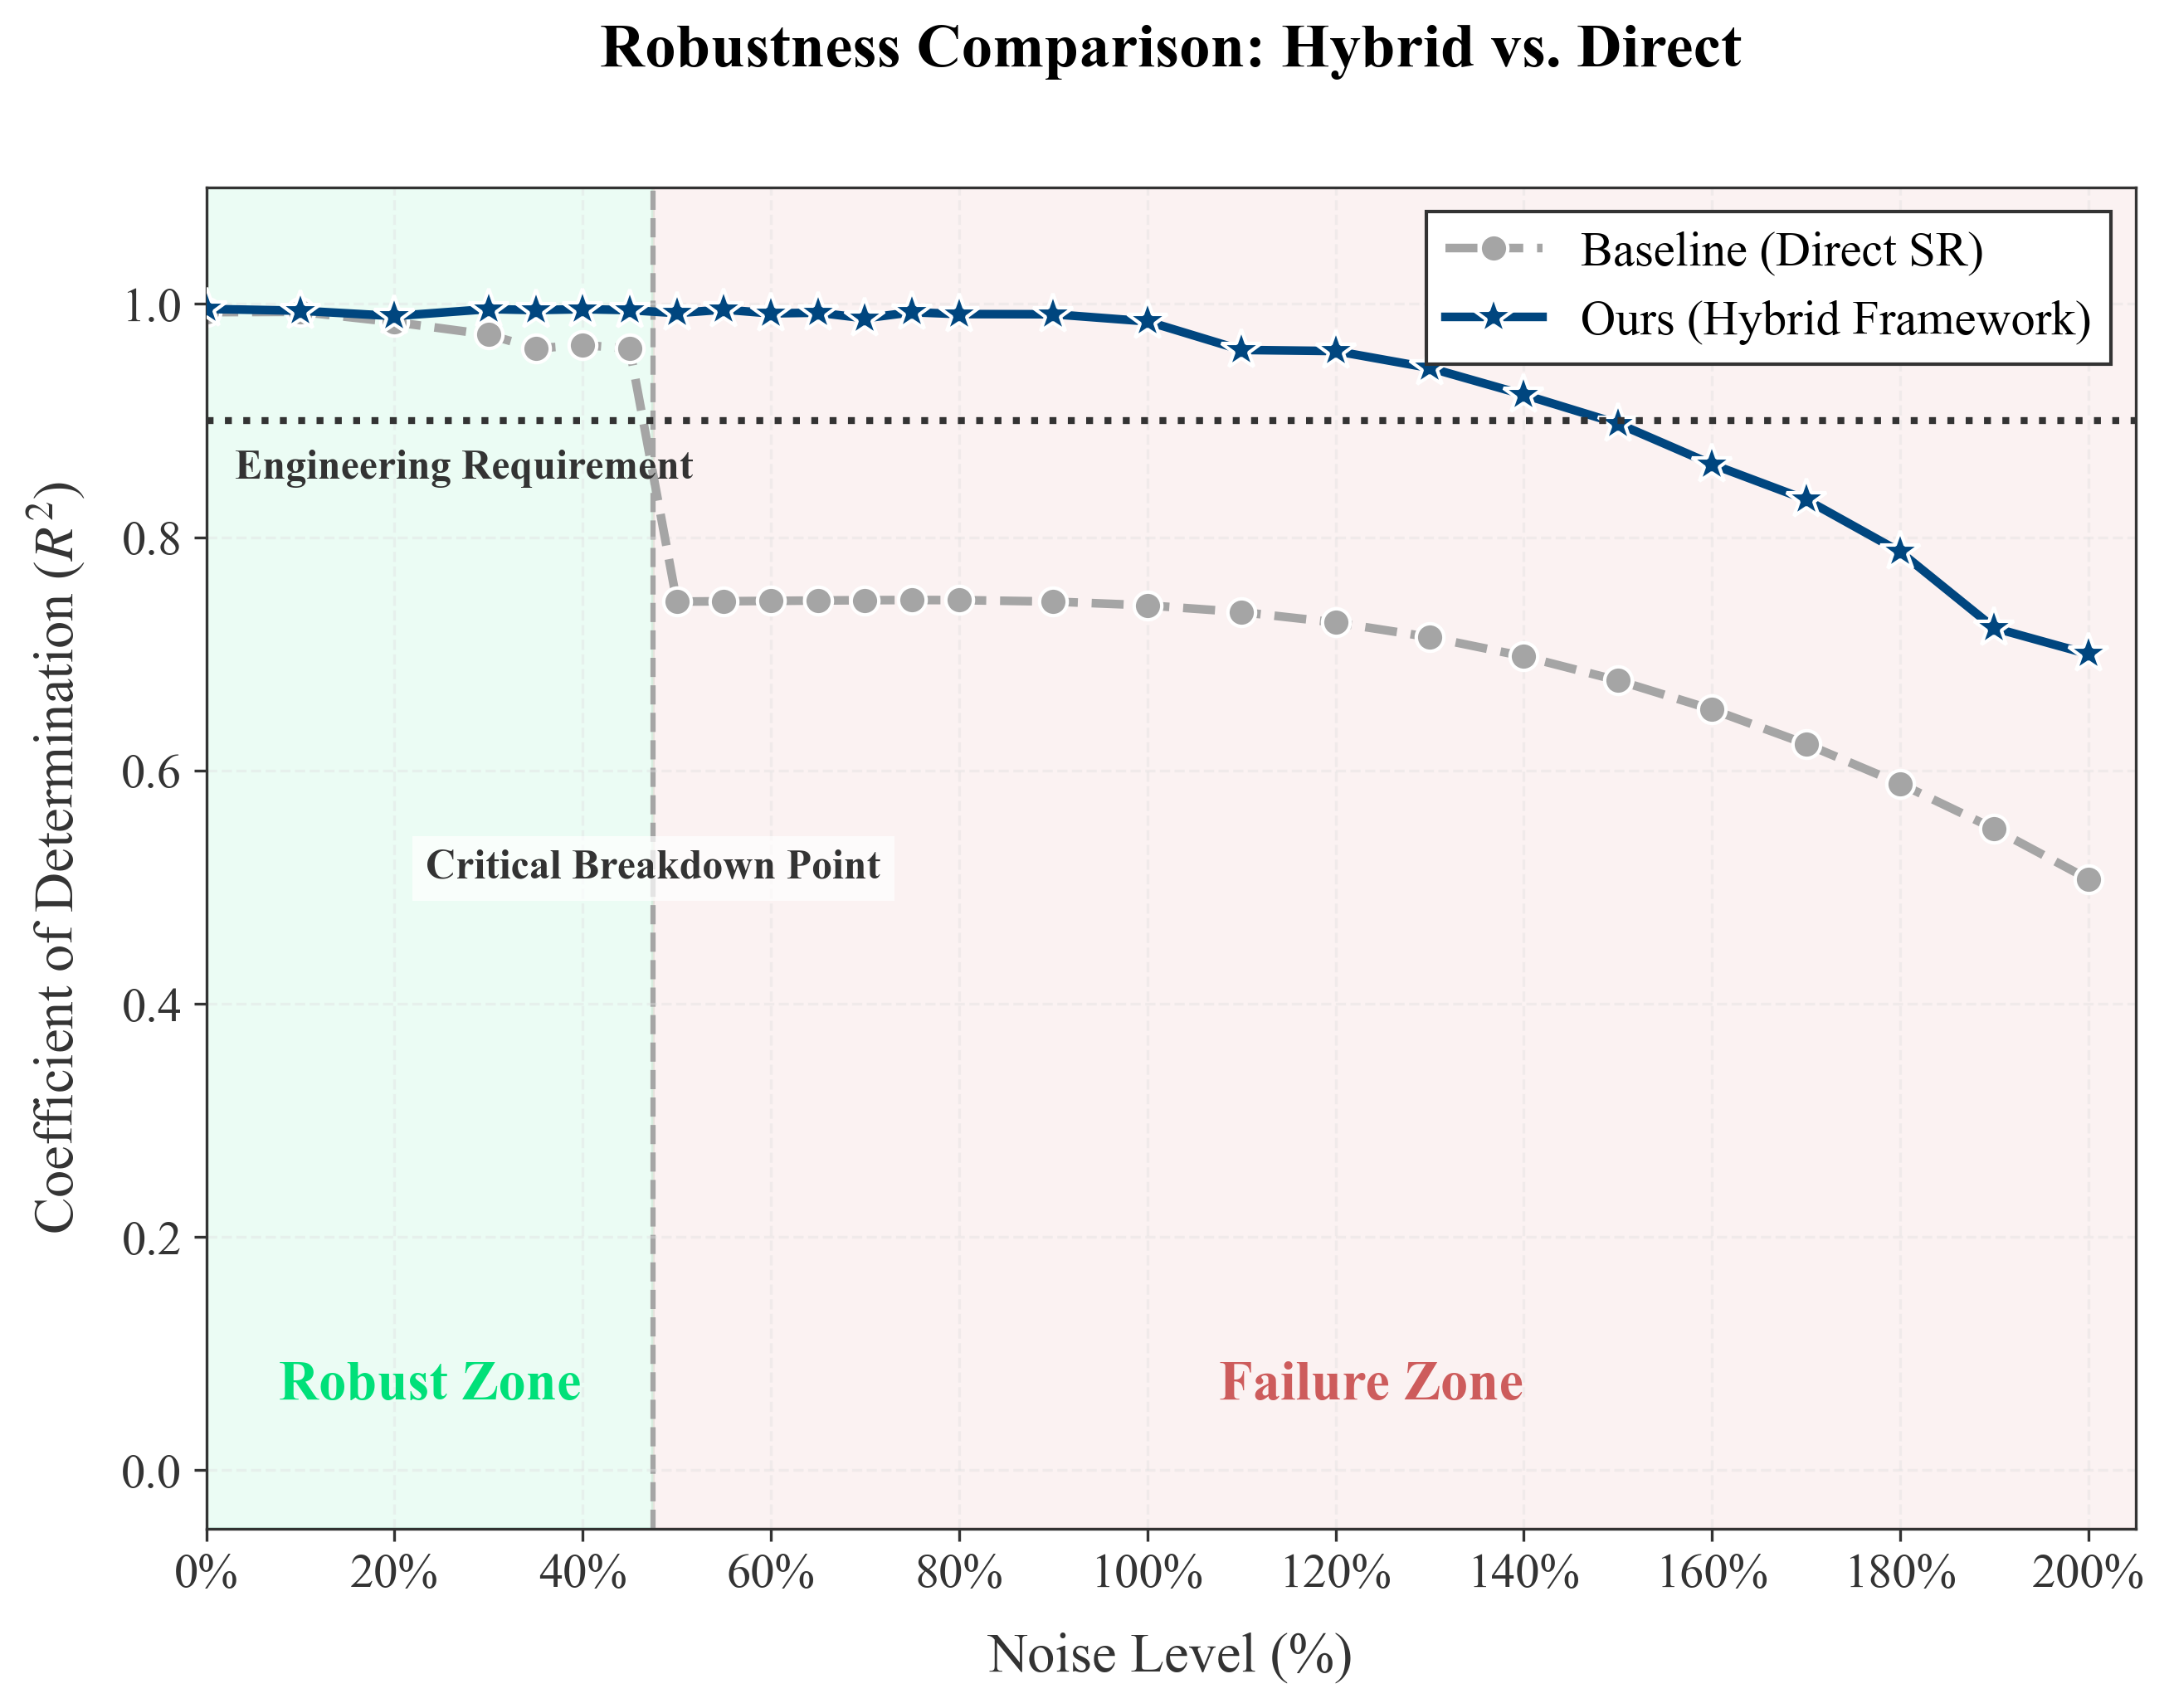

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import os
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与风格设置
# ==========================================
# 加载 VizConfig 中的学术风格配置
VizConfig.set_style()

# 引用配置中的常量，方便后续使用
TITLE_SIZE = VizConfig.TITLE_SIZE
LABEL_SIZE = VizConfig.LABEL_SIZE
TICK_SIZE = VizConfig.TICK_SIZE
LEGEND_SIZE = VizConfig.LEGEND_SIZE

OUTPUT_DIR = "Refined_Results_v4"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ==========================================
# 1. 数据读取 (Data Loading)
# ==========================================
csv_path = os.path.join(OUTPUT_DIR, "final_summary_r2.csv")

# 检查是否存在真实数据文件
if not os.path.exists(csv_path):
    print(f"提示：未找到文件 {csv_path}，使用模拟数据进行演示。")
    # 构造模拟数据用于展示图表效果
    # 模拟噪声比例从 0% 到 200%
    x_raw = np.linspace(0, 2.0, 21) 
    
    # 模拟 Baseline (Direct SR) 的表现：在 50% 噪声处发生崩溃 (Sigmoid 形状下降)
    y_direct = 0.99 - (0.99 / (1 + np.exp(-10 * (x_raw - 0.5)))) - 0.1 * x_raw
    y_direct[y_direct < -0.1] = -0.1 # 截断底部，防止过低
    
    # 模拟 Ours (Hybrid Framework) 的表现：随噪声线性缓慢下降，保持较高的鲁棒性
    y_hybrid = 0.99 - 0.15 * x_raw 
else:
    # 读取真实的实验结果数据
    df = pd.read_csv(csv_path)
    x_raw = df['Noise_Ratio'].values
    y_direct = df['R2_Direct_PySR'].values
    y_hybrid = df['R2_Hybrid_PySR'].values

# ==========================================
# 2. 绘图初始化 (Plot Initialization)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 定义关键的崩溃点 (Critical Breakdown Point) 位置，用于划分区域
cliff_x = 0.475 
max_x = 2.0     # X轴显示的最大范围

# ==========================================
# 3. 绘制背景区域与分界线 (Zones & Thresholds)
# ==========================================
# A. 绘制背景色块，直观区分"鲁棒区"和"失效区"
# 左侧：鲁棒区域 (Robust Zone) - 浅绿色背景
ax.axvspan(xmin=-0.05, xmax=cliff_x, color=VizConfig.COLOR_SUCCESS, alpha=0.08, zorder=0) 
# 右侧：失效区域 (Failure Zone) - 浅红色背景
ax.axvspan(xmin=cliff_x, xmax=max_x+0.1, color=VizConfig.COLOR_HIGHLIGHT, alpha=0.08, zorder=0)

# B. 绘制垂直分界线
ax.axvline(x=cliff_x, color=VizConfig.COLOR_SECONDARY, linestyle='--', linewidth=1.5, zorder=1)
# 在分界线上添加标注文字
ax.text(x=cliff_x, y=0.5, s="Critical Breakdown Point", 
        color=VizConfig.COLOR_AXIS, fontsize=12, ha='center', va='bottom', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)) # 添加白色背景以防文字与线重叠

# ==========================================
# 4. 绘制数据曲线 (Data Curves)
# ==========================================
# A. Baseline: Direct SR
# 使用次要颜色 (灰色) 和虚线，表示这是对照组
# 只有边框颜色，中心为白色，增加层次感
line_base, = ax.plot(x_raw, y_direct, marker='o', markersize=8, linewidth=2.5, 
                     color=VizConfig.COLOR_SECONDARY, linestyle='--', label='Baseline (Direct SR)', zorder=2,
                     markeredgecolor='white', markeredgewidth=1)

# B. Ours: Hybrid Framework
# 使用主色 (深蓝) 和实线，强调这是本文提出的方法
# 使用星号标记，突出显示
line_ours, = ax.plot(x_raw, y_hybrid, marker='*', markersize=12, linewidth=2.5, 
                     color=VizConfig.COLOR_MAIN, linestyle='-', label='Ours (Hybrid Framework)', zorder=3,
                     markeredgecolor='white', markeredgewidth=1)

# ==========================================
# 6. 添加辅助标注 (Annotations)
# ==========================================
# A. 区域名称标注 (放置在底部)
text_y_pos = 0.05 
# "Robust Zone" (绿色)
ax.text(x=cliff_x/2, y=text_y_pos, s="Robust Zone", 
        color=VizConfig.COLOR_SUCCESS, fontsize=VizConfig.LABEL_SIZE, fontweight='bold', ha='center', va='bottom')
# "Failure Zone" (红色)
ax.text(x=cliff_x + (max_x - cliff_x)/2, y=text_y_pos, s="Failure Zone", 
        color=VizConfig.COLOR_HIGHLIGHT, fontsize=VizConfig.LABEL_SIZE, fontweight='bold', ha='center', va='bottom')

# B. 工程要求线 (Engineering Requirement Line)
# 在 R2=0.9 处绘制一条水平虚线，表示工程上可接受的最低精度
ax.axhline(y=0.9, color=VizConfig.COLOR_AXIS, linestyle=':', linewidth=2, zorder=3)
ax.text(x=0.03, y=0.85, s="Engineering Requirement", fontsize=12, fontweight='bold', color=VizConfig.COLOR_AXIS)

# ==========================================
# 7. 坐标轴与图例设置 (Axes & Legend)
# ==========================================
# A. X轴刻度设置
# 每隔 20% 设置一个刻度
x_ticks = np.arange(0, 2.1, 0.2)
# 将数值转换为百分比字符串 (如 "20%")
x_labels = [f"{int(val*100)}%" for val in x_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, fontsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=TICK_SIZE)

# B. 标题与标签
ax.set_xlabel("Noise Level (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel(r"Coefficient of Determination ($R^2$)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_title("Robustness Comparison: Hybrid vs. Direct", fontsize=TITLE_SIZE, pad=35, fontweight='bold')

# C. 图例
# 放置在右上角，带边框
ax.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True, facecolor='white', framealpha=1) 

# D. 坐标轴范围与网格
ax.set_xlim(0, 2.05)
ax.set_ylim(-0.05, 1.1) 
ax.grid(True, linestyle='--', alpha=0.4, color=VizConfig.COLOR_GRID, zorder=1)

# ==========================================
# 8. 保存与输出
# ==========================================
# 自动调整布局，pad_inches 防止边缘被裁剪
plt.tight_layout()
output_path = os.path.join(OUTPUT_DIR, "6.pdf")
# 保存为高精度 PDF
plt.savefig(output_path, dpi=VizConfig.DPI, bbox_inches='tight', pad_inches=0.1) 

print(f"对比图已保存至: {output_path}")
plt.show()